# 04.3 - Origin Classification with ModernBERT + Extra Review Text (UNSCRUBBED)

This notebook extends **04.2** by concatenating three additional review columns to the input text:

- `Notes` - background info (farm, processing, roaster commentary)
- `Who Should Drink It` - consumer-oriented description
- `Bottom Line` - short summary sentence

## LEAKAGE WARNING

These columns were written *with* knowledge of origin. Preliminary check shows the true country name
appears literally in `Notes` ~50% of the time and in `Bottom Line` ~62% of the time. Any F1 improvement
over 04.2 here is partly the model learning to **read the country name out of the text** rather than
learning the flavor-to-origin mapping.

This notebook is paired with **04.4**, which scrubs country and region names before training to isolate
the real extra-flavor signal.

## Configuration

- Model: `answerdotai/ModernBERT-base` (same as 04.2)
- Best config from 04.2 seed harness: `lr=3e-5`, plain CE, 12 epochs, early-stop patience 3
- Single seed=42 for speed. Seed harness only worth running if the headline is close to 04.2.

## Baseline to compare against

- 04.2 ModernBERT on `text_basic_plus_aspects` alone, seed 42: **Macro-F1 = 0.182**


In [9]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback


In [10]:
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'answerdotai/ModernBERT-base'
TEXT_COLUMN = 'text_full_concat'
MAX_LENGTH = 256

# Best config from 04.2 seed harness
BEST_LR = 3e-5
USE_CLASS_WEIGHTS = False  # plain CE

# Training config (same as 04.2)
NUM_TRAIN_EPOCHS = 12
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 3
USE_FP16 = True

OUTPUT_DIR_ROOT = 'artifacts/origin_finetuning_modernbert_fulltext_unscrubbed'
os.makedirs(OUTPUT_DIR_ROOT, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)


Device: cuda


## Load data and build concatenated text

In [11]:
df = pd.read_csv('Data/final_coffee_reviews.csv')


def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()


def normalize_text(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


# Concatenate the four review columns. Skip empty cells - no placeholder.
EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']


def concat_review_text(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            pieces.append(normalize_text(v))
    return ' '.join(p for p in pieces if p)


df['text_full_concat'] = df.apply(concat_review_text, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)

df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

print('Rows:', len(work), 'Classes:', work['origin_country'].nunique())
print('Avg concat text length (chars):', int(work['text_full_concat'].str.len().mean()))


Rows: 6820 Classes: 15
Avg concat text length (chars): 873


## Leakage check (THIS IS THE POINT - expect HIGH leakage here)

In [12]:
# Leakage check: how often does the country name literally appear in the text?
def contains_own_country(row):
    t = row['text_full_concat'].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False


work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'OVERALL LEAKAGE RATE: {leak_rate:.1%} of samples contain their true country name in the text.')
print()
print('Per-country leakage rate:')
print(work.groupby('origin_country')['leaks_country'].mean().round(3).sort_values(ascending=False).to_string())
print()
print('--- 3 training samples (first 500 chars) ---')
for i in range(3):
    row = work.iloc[i]
    preview = row['text_full_concat'][:500]
    print(f"[{row['origin_country']}]  {preview}...")
    print()


OVERALL LEAKAGE RATE: 73.7% of samples contain their true country name in the text.

Per-country leakage rate:
origin_country
Kenya            0.941
Rwanda           0.926
Ethiopia         0.866
Brazil           0.810
Costa Rica       0.767
Guatemala        0.745
Peru             0.738
Nicaragua        0.728
Honduras         0.707
Colombia         0.700
Panama           0.641
El Salvador      0.638
Mexico           0.624
Indonesia        0.431
United States    0.013

--- 3 training samples (first 500 chars) ---
[Colombia]  evaluated at proportions of 5 grams of instant coffee powder mixed with 8 5 ounces 250 ml of hot water caramel toned richly sweet dark caramel magnolia like flowers cedar baker s chocolate a hint of apricot in aroma and cup sweet toned in structure with brisk acidity smooth mouthfeel the finish is crisply sweet and resonant with lingering notes of caramel and apricot the green coffee for this product was produced in colombia from trees of the arabica species it was s

## Stratified 70/15/15 split (same RANDOM_STATE as 04.2)

In [13]:
y = work['origin_country']
row_idx = work.index

train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

label_names = sorted(work['origin_country'].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_texts = work.loc[train_idx, TEXT_COLUMN].fillna('').tolist()
val_texts   = work.loc[val_idx,   TEXT_COLUMN].fillna('').tolist()
test_texts  = work.loc[test_idx,  TEXT_COLUMN].fillna('').tolist()

train_labels = work.loc[train_idx, 'origin_country'].map(label2id).tolist()
val_labels   = work.loc[val_idx,   'origin_country'].map(label2id).tolist()
test_labels  = work.loc[test_idx,  'origin_country'].map(label2id).tolist()

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_names)),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)


Train/Val/Test: 4774 1023 1023


## Tokenize and build datasets

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


class CoffeeOriginDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = CoffeeOriginDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = CoffeeOriginDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = CoffeeOriginDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)
print('Datasets ready.')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')


Datasets ready.
Train: 4774, Val: 1023, Test: 1023


## Metrics, Trainer, and run_one (copied from 04.2)

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def build_training_args(output_dir: str, learning_rate: float):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='epoch',
        disable_tqdm=True,
        report_to='none',
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )


def run_one(learning_rate: float, use_class_weights: bool, tag: str):
    set_seed(RANDOM_STATE)
    out_dir = os.path.join(OUTPUT_DIR_ROOT, tag)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    args = build_training_args(out_dir, learning_rate)
    trainer_cls = WeightedTrainer if use_class_weights else Trainer
    extra = dict(class_weights=class_weights_tensor) if use_class_weights else {}
    trainer = trainer_cls(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        **extra,
    )
    try:
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    print(f"\n=== Training {tag} | lr={learning_rate} | weighted={use_class_weights} ===")
    train_out = trainer.train()
    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix='test')
    return trainer, train_out, val_metrics, test_metrics


## Train with best config from 04.2 seed harness

Expected runtime: ~4 minutes on a modern GPU.

In [16]:
tag = f'unscrubbed_lr{BEST_LR:.0e}_seed{RANDOM_STATE}'
trainer_trained, train_out, val_m, test_m = run_one(
    BEST_LR, use_class_weights=USE_CLASS_WEIGHTS, tag=tag
)

headline = {
    'tag': tag,
    'lr': BEST_LR,
    'weighted': USE_CLASS_WEIGHTS,
    'seed': RANDOM_STATE,
    'val_f1_macro': val_m['eval_f1_macro'],
    'val_balanced_accuracy': val_m['eval_balanced_accuracy'],
    'val_accuracy': val_m['eval_accuracy'],
    'test_f1_macro': test_m['test_f1_macro'],
    'test_balanced_accuracy': test_m['test_balanced_accuracy'],
    'test_accuracy': test_m['test_accuracy'],
    'leakage_rate': leak_rate,
}
print()
print(json.dumps(headline, indent=2))


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training unscrubbed_lr3e-05_seed42 | lr=3e-05 | weighted=False ===
{'loss': '3.896', 'grad_norm': '34.46', 'learning_rate': '2.933e-05', 'epoch': '1'}
{'eval_loss': '0.9262', 'eval_accuracy': '0.739', 'eval_balanced_accuracy': '0.5054', 'eval_precision_macro': '0.5487', 'eval_recall_macro': '0.5054', 'eval_f1_macro': '0.5113', 'eval_runtime': '7.831', 'eval_samples_per_second': '130.6', 'eval_steps_per_second': '4.086', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.9985', 'grad_norm': '23.08', 'learning_rate': '2.667e-05', 'epoch': '2'}
{'eval_loss': '0.4581', 'eval_accuracy': '0.8788', 'eval_balanced_accuracy': '0.8309', 'eval_precision_macro': '0.8545', 'eval_recall_macro': '0.8309', 'eval_f1_macro': '0.8373', 'eval_runtime': '9.66', 'eval_samples_per_second': '105.9', 'eval_steps_per_second': '3.313', 'epoch': '2'}


...

{'loss': '9.584e-05', 'grad_norm': '0.001991', 'learning_rate': '2.766e-06', 'epoch': '11'}
{'eval_loss': '0.6274', 'eval_accuracy': '0.8944', 'eval_balanced_accuracy': '0.8548', 'eval_precision_macro': '0.8818', 'eval_recall_macro': '0.8548', 'eval_f1_macro': '0.8669', 'eval_runtime': '8.052', 'eval_samples_per_second': '127', 'eval_steps_per_second': '3.974', 'epoch': '11'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1358', 'train_samples_per_second': '42.19', 'train_steps_per_second': '1.326', 'train_loss': '0.5246', 'epoch': '11'}
{'eval_loss': '0.6371', 'eval_accuracy': '0.8993', 'eval_balanced_accuracy': '0.8645', 'eval_precision_macro': '0.8905', 'eval_recall_macro': '0.8645', 'eval_f1_macro': '0.8762', 'eval_runtime': '9.406', 'eval_samples_per_second': '108.8', 'eval_steps_per_second': '3.402', 'epoch': '11'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '0.4775', 'test_accuracy': '0.911', 'test_balanced_accuracy': '0.8603', 'test_precision_macro': '0.9259', 'test_recall_macro': '0.8603', 'test_f1_macro': '0.8881', 'test_runtime': '8.133', 'test_samples_per_second': '125.8', 'test_steps_per_second': '3.935', 'epoch': '11'}

{
  "tag": "unscrubbed_lr3e-05_seed42",
  "lr": 3e-05,
  "weighted": false,
  "seed": 42,
  "val_f1_macro": 0.8761952999253376,
  "val_balanced_accuracy": 0.8645366880003605,
  "val_accuracy": 0.8993157380254154,
  "test_f1_macro": 0.8880870580990062,
  "test_balanced_accuracy": 0.8603048137195591,
  "test_accuracy": 0.9110459433040078,
  "leakage_rate": 0.7365102639296187
}


## Per-class report and confusion matrix

== Test headline ==
Macro-F1:          0.8881
Balanced Accuracy: 0.8603
Accuracy:          0.9110

Test per-class report:
               precision    recall  f1-score   support

     Ethiopia      0.941     0.953     0.947       299
     Colombia      0.801     0.926     0.859       148
        Kenya      1.000     0.943     0.971       105
    Guatemala      0.876     0.929     0.902        84
    Indonesia      0.861     0.912     0.886        68
   Costa Rica      0.940     0.839     0.887        56
       Panama      0.926     0.943     0.935        53
United States      1.000     0.978     0.989        45
  El Salvador      0.871     0.750     0.806        36
       Brazil      0.852     0.767     0.807        30
       Rwanda      1.000     0.926     0.962        27
         Peru      0.938     0.750     0.833        20
    Nicaragua      1.000     0.789     0.882        19
     Honduras      0.882     0.833     0.857        18
       Mexico      1.000     0.667     0.800        

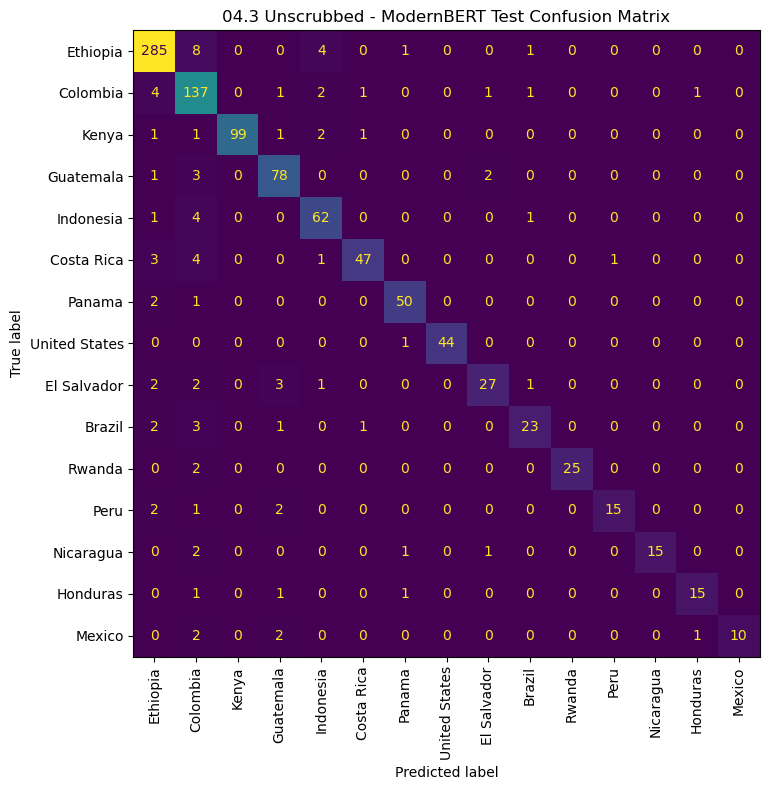

In [17]:
test_pred_output = trainer_trained.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)
test_true_labels = [id2label[i] for i in test_labels]
test_pred_labels = [id2label[i] for i in test_pred_ids]

print('== Test headline ==')
print(f"Macro-F1:          {f1_score(test_true_labels, test_pred_labels, average='macro', zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_true_labels, test_pred_labels):.4f}")
print(f"Accuracy:          {accuracy_score(test_true_labels, test_pred_labels):.4f}")

class_order = work['origin_country'].value_counts().index.tolist()
print()
print('Test per-class report:')
print(classification_report(test_true_labels, test_pred_labels, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(test_true_labels, test_pred_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('04.3 Unscrubbed - ModernBERT Test Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [18]:
with open(os.path.join(OUTPUT_DIR_ROOT, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '04.3_Origin_Classification_ModernBERT_FullText_Unscrubbed',
        'model': MODEL_CHECKPOINT,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrubbed': False,
        'leakage_rate': leak_rate,
        'config': {
            'lr': BEST_LR, 'weighted': USE_CLASS_WEIGHTS,
            'epochs': NUM_TRAIN_EPOCHS, 'early_stop_patience': EARLY_STOP_PATIENCE,
            'seed': RANDOM_STATE, 'max_length': MAX_LENGTH,
        },
        'headline': headline,
        'baselines': {
            'modernbert_04_2_blind_assessment_only_seed42': 0.1823,
        },
    }, f, indent=2)
print('Saved', os.path.join(OUTPUT_DIR_ROOT, 'results.json'))


Saved artifacts/origin_finetuning_modernbert_fulltext_unscrubbed\results.json


## Interpretation

Compare this notebook's test Macro-F1 against **04.2 baseline (0.182)**:

- If F1 >> 0.5: massive leakage confirmed. The model is reading country names, not learning flavor.
- If F1 ~ 0.2-0.4: partial leakage. Extra text helps somewhat, but the signal is mixed.
- If F1 ~ 0.18: extra text adds no meaningful signal even with country names present.

**The important comparison is against 04.4**, where country/region names are scrubbed. The gap
between 04.3 and 04.4 quantifies exactly how much of the "extra text helps" illusion is leakage.